# Deep Learning Implementation

## Import

In [1]:
import os  
os.environ['KMP_DUPLICATE_LIB_OK']='True' # fix dead kernel

In [2]:
import albumentations as A
import torch
import torch.nn as nn
import torch.optim as optim

from albumentations.pytorch import ToTensorV2
from torchvision import models

/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Load Model

In [3]:
import ssl
import certifi
import urllib.request

# Set the default SSL context to use the  certificate bundle
ssl._create_default_https_context = ssl._create_unverified_context

# Alternatively, you can set the context for urllib globally
context = ssl.create_default_context(cafile=certifi.where())
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
urllib.request.install_opener(opener)

weights = models.ResNet50_Weights.DEFAULT
net = models.resnet50(weights=weights)
net.fc = nn.Linear(net.fc.in_features, 4) # four classes
net = net.to("cuda" if torch.cuda.is_available() else "cpu")

## Prepare the Dataset

### Load Training/Testing Datasets

In [4]:
from pathlib import Path
from collections import Counter
from data_augmentation import cnn_only_augmentation

train_directory = Path(r"/scratch/user/al63rt.tran/Train")
validation_directory = Path(r"/scratch/user/al63rt.tran/Validation")

class_names = ["Uninhabited", "Empty", "Rebuilding", "Rebuilt"]

class_sampling = {
    "Uninhabited": "all",
    "Rebuilding": "all",
    "Empty": 800,
    "Rebuilt": 800,
}

augmentation_factors = {
    "Uninhabited": 8,
    "Rebuilding": 5,
}

### Set Up Training Dataset

In [5]:
from train_utils import (
    _build_address_list,
    build_train_loader,
    train_model,
    _live_plot,
)

train_folders = sorted([p for p in train_directory.iterdir() if p.is_dir()])

train_addrs = []
for folder in train_folders:
    addrs_i, class_names_i = _build_address_list(str(folder), class_names=class_names)
    train_addrs.extend(addrs_i)

meta = {
    "train_addrs": train_addrs,
    "minority_classes": [],  
}

print("Train folders:", [p.name for p in train_folders])

Train folders: ['.ipynb_checkpoints', 'Train 2011', 'Train 2012', 'Train 2013', 'Train 2014', 'Train 2015', 'Train 2016']


### Set Up Validation Dataset

In [6]:
minority_aug, base = cnn_only_augmentation()

augmentation_ds = {
    "aug_t": minority_aug,
    "base_t": base,
}

In [7]:
validation_loader = None

if validation_directory.exists():
    validation_folders = sorted([p for p in validation_directory.iterdir() if p.is_dir()])
    validation_addrs = []

    for folder in validation_folders:
        addrs_i, _ = _build_address_list(str(folder), class_names=class_names)
        validation_addrs.extend(addrs_i)

    validation_meta = {
        "train_addrs": validation_addrs,
        "minority_classes": [],   
        "train_pairs": [(i, False) for i in range(len(validation_addrs))],
    }

    validation_loader = build_train_loader(
        augmentation_ds=augmentation_ds,
        meta=validation_meta,
        batch_size=1,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        max_frames=64,
    )

    print("Validation folders:", [p.name for p in validation_folders])

Validation folders: ['.ipynb_checkpoints', 'Validation 2011', 'Validation 2012', 'Validation 2013', 'Validation 2014', 'Validation 2015', 'Validation 2016']


### Freeze Layers

In [8]:
import torch.nn as nn

net.train()  

for m in net.modules():
    if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        m.eval()
        for p in m.parameters():
            p.requires_grad = False

### Hyperparameter Setting

In [9]:
optimizer = torch.optim.AdamW(
    net.parameters(),
    lr=1e-5,
    weight_decay=1e-3,
)

lr = [1e-5, 1e-6]
lr_epochs = [1, 25]   

### Implement Training

In [14]:
import importlib
import train_utils

importlib.reload(train_utils)

<module 'train_utils' from '/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/train_utils.py'>

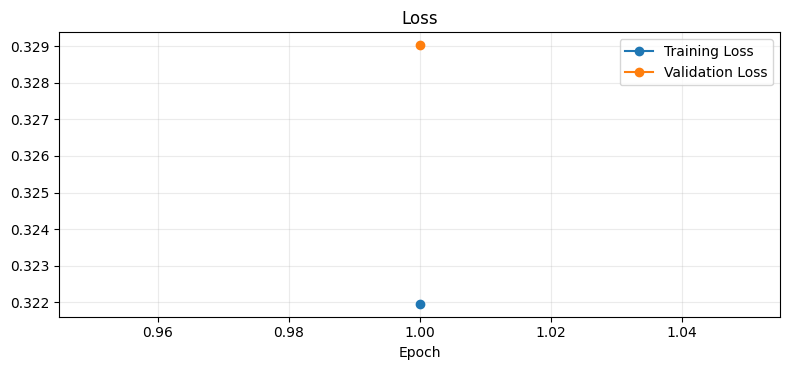

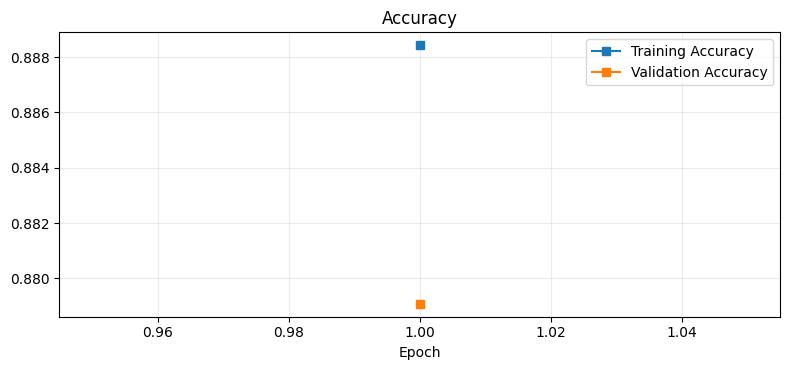

epoch 2/8:   0%|          | 0/3128 [00:00<?, ?address/s]

validat:   0%|          | 0/3523 [00:00<?, ?address/s]

In [ ]:
# Set training information directory
csv_path = r"/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/resnet50.csv"

history = train_model(
    model=net,
    epochs=8,
    optimizer=optimizer,
    mode="single",
    lr=lr,
    lr_epochs=lr_epochs,
    device="cuda" if torch.cuda.is_available() else "cpu",
    colour="green",
    validation_loader=validation_loader,
    csv_path=csv_path,
    checkpoint_dir=r"/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/resnet50",
    checkpoint_prefix="resnet50",
    freeze_bn=True,
    plot_fn=_live_plot,
    class_sampling=class_sampling,
    augmentation_factors=augmentation_factors,
    augmentation_ds=augmentation_ds,
    meta=meta,
    class_names=class_names,
    seed=42,
    dropout_p=0.2,
    apply_dropout=True,
)

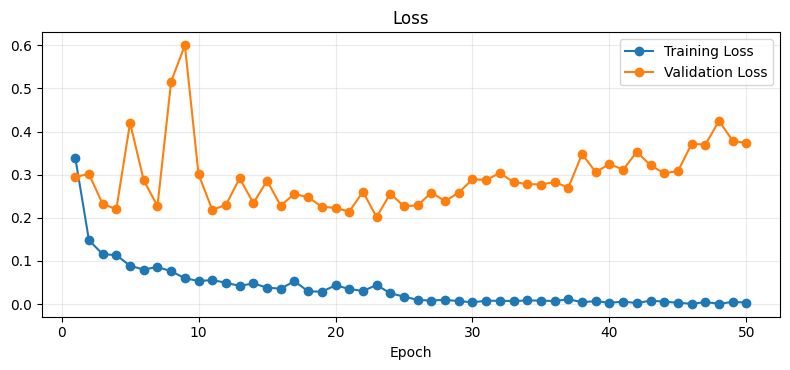

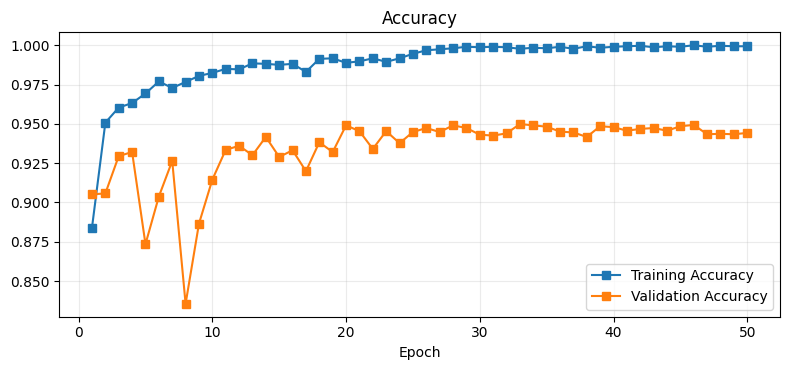

In [11]:
# Set training information directory
csv_path = r"/scratch/user/al63rt.tran/resnet50_50ep.csv"

history = train_model(
    model=net,
    epochs=6,
    optimizer=optimizer,
    mode="single",
    lr=lr,
    lr_epochs=lr_epochs,
    device="cuda" if torch.cuda.is_available() else "cpu",
    colour="green",
    validation_loader=validation_loader,
    csv_path=csv_path,
    checkpoint_dir=r"/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/resnet50",
    checkpoint_prefix="resnet50",
    freeze_bn=True,
    plot_fn=_live_plot,
    class_sampling=class_sampling,
    augmentation_factors=augmentation_factors,
    augmentation_ds=augmentation_ds,
    meta=meta,
    class_names=class_names,
    seed=42,
    dropout_p=0.2,
    apply_dropout=True,
)

## Restore Best Model

In [4]:
from pathlib import Path
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
path = Path("/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/resnet50/resnet50_epoch_021.pth")

net = models.resnet50(weights=None)  

net.fc = nn.Sequential(
    nn.Dropout(p=0.2),  
    nn.Linear(net.fc.in_features, 4),
)

ckpt = torch.load(path, map_location=device)

# get actual weights
state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt

# if saved with DataParallel, remove "module." prefix
if len(state_dict) > 0 and next(iter(state_dict)).startswith("module."):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

net = net.to(device)
net.load_state_dict(state_dict, strict=True)
net.eval()

print("Loaded epoch:", ckpt.get("epoch"))
print("Validation loss:", ckpt.get("validation_loss"))
print("Moving-average validation loss:", ckpt.get("validation_loss_ma"))

Loaded epoch: 21
Val loss: 0.214523598674797
Val loss MA3: 0.22107380002390856


## Plot Confusion Matrix

In [9]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix as confusion
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from tqdm.notebook import tqdm

@torch.no_grad()
def confusion_matrix(
    model,
    loader,
    class_names,
    device=None,
    title="Confusion Matrix",
    cmap="Blues",
    save_path: str | None = None,   
    dpi: int = 300,                 
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.eval()
    model.to(device)

    y_true_list = []
    y_pred_list = []

    for frames, label in tqdm(loader):
        frames = frames[0].to(device, non_blocking=True)  # [K,3,H,W]
        y_true = int(label.item())

        logits = model(frames)            # [K,C]
        bag_logits = logits.mean(dim=0)   # [C]

        y_pred = int(bag_logits.argmax().item())

        y_true_list.append(y_true)
        y_pred_list.append(y_pred)

    print(classification_report(
        y_true_list,
        y_pred_list,
        labels=list(range(len(class_names))),
        target_names=class_names,
        digits=3,
        zero_division=0
    ))

    cm_counts = confusion(
        y_true_list, y_pred_list,
        labels=list(range(len(class_names)))
    )

    cm_norm = confusion(
        y_true_list, y_pred_list,
        labels=list(range(len(class_names))),
        normalize="true"
    )

    # plot
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
    disp.plot(ax=ax, cmap=cmap, values_format=".2f", colorbar=True)
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    # save confusion matrix
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True) if os.path.dirname(save_path) else None
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved confusion matrix to: {save_path}")

    plt.show()

    return cm_counts, cm_norm

  0%|          | 0/3532 [00:00<?, ?it/s]

              precision    recall  f1-score   support

 Uninhabited      0.814     0.941     0.873        51
       Empty      0.912     0.945     0.928       993
  Rebuilding      0.560     0.636     0.596        66
     Rebuilt      0.976     0.954     0.965      2422

    accuracy                          0.945      3532
   macro avg      0.815     0.869     0.840      3532
weighted avg      0.947     0.945     0.946      3532

Saved confusion matrix to: /scratch/user/al63rt.tran/cm_resnet50.png


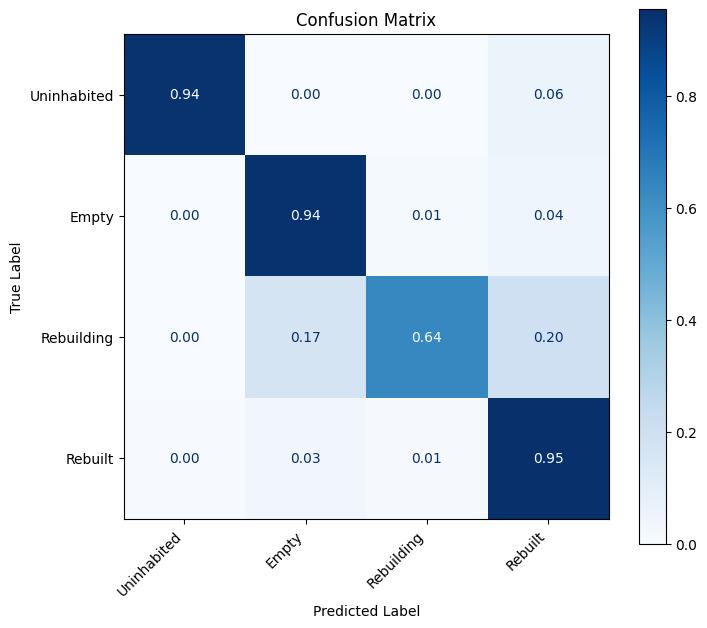

In [10]:
cm, cm_norm = confusion_matrix(
    model=net,
    loader=validation_loader,
    class_names=class_names,
    device="cuda",
    cmap="Blues",
    save_path="/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/cm_resnet50.png",
    dpi=300,
)